In [1]:
# IMPORTS

import numpy
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as tv_models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

In [2]:
import helper_utils

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {DEVICE}")

Using Device: cuda


In [4]:
# Load the dataset path
dataset_path = "./AI_VS_Real"  

# Analyzes the dataset splits at the given path and prints a count of images for each class.
helper_utils.dataset_images_per_class(dataset_path)

Analyzing dataset at: ./AI_VS_Real

— Train —
Fake: 5000 images
Real: 5000 images

— Test —
Fake: 1000 images
Real: 1000 images



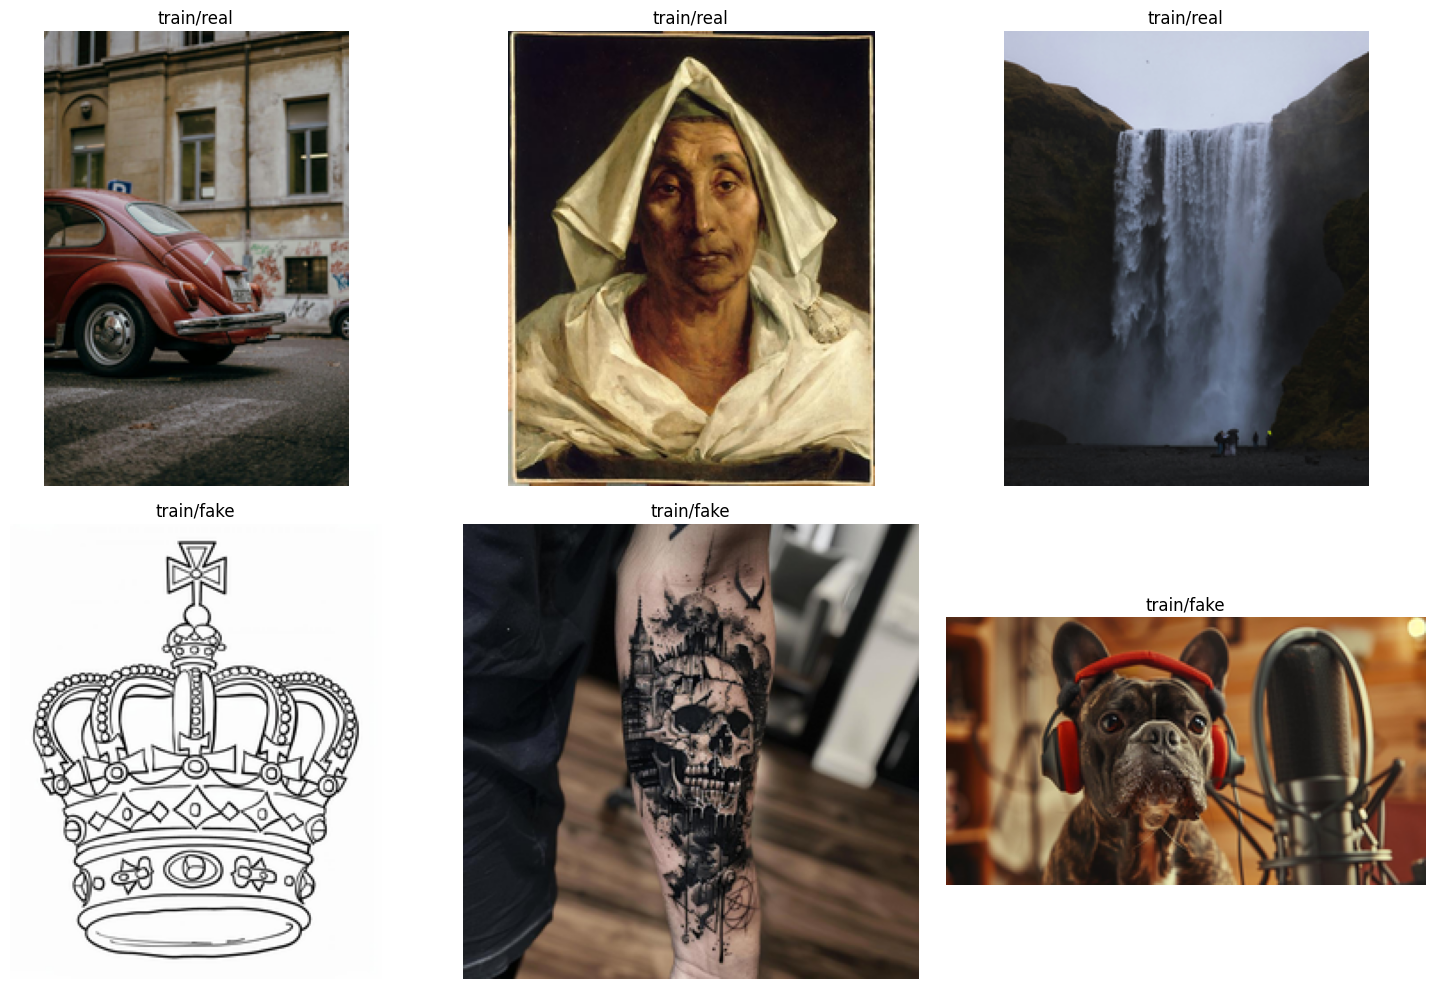

In [5]:
# Randomly select and display a grid of sample images from the 'train' folder.
helper_utils.display_train_images(dataset_path)

In [6]:
#loading data with ImageFolder

In [7]:
#create_dataset_splits

def create_dataset_splits(data_path):
    """
    It creates training and validation datasets from a directory structure using ImageFolder.

    Args:
        data_path (str): The root path to the dataset directory, which should contain 'train' and 'validation/test' subdirectories.

    Returns:
        tuple: A tuple containing the train_dataset and validation_dataset (train_dataset, validation_dataset).
    """

    # Construct the full path to the training data directory.
    train_path = data_path + "/train"
    # Construct the full path to the validation data directory.
    val_path = data_path + "/test"
        
    # Create the train dataset using ImageFolder
    train_dataset = ImageFolder(
        # Set the root to train dataset path
        root=train_path,
    ) 

    # Create the validation dataset using ImageFolder
    val_dataset = ImageFolder(
        # Set the root to validation dataset path
        root=val_path,
    ) 

    return train_dataset, val_dataset

In [8]:
# Verify that the function loads the datasets
temp_train, temp_val = create_dataset_splits(dataset_path)

print("--- Training Dataset ---")
print(temp_train)
print("\n--- Validation Dataset ---")
print(temp_val)

--- Training Dataset ---
Dataset ImageFolder
    Number of datapoints: 10000
    Root location: ./AI_VS_Real/train

--- Validation Dataset ---
Dataset ImageFolder
    Number of datapoints: 2000
    Root location: ./AI_VS_Real/test


In [9]:
# now it is time to define the transformations that will prepare our images for the neural network

In [10]:
# Defining the standard mean values for the ImageNet dataset
imagenet_mean = torch.tensor([0.485, 0.456, 0.406])

# Defining the standard standard deviation values for the ImageNet dataset
imagenet_std = torch.tensor([0.229, 0.224, 0.225])

In [11]:
#define_transformations

def define_transformations(mean=imagenet_mean, std=imagenet_std):
    """
    it defines separate series of image transformations for training and validation datasets.

    Args:
        mean (list or tuple): The mean values (for each channel, e.g., RGB) calculated from ImageNet.
        std (list or tuple): The standard deviation values (for each channel) calculated from ImageNet.

    Returns:
        tuple: A tuple containing two `torchvision.transforms.Compose` objects:
               - The first for training transformations.
               - The second for validation transformations.
    """

    # Create a Compose object to chain multiple transformations together for the training set
    
    # Initialize 'train_transform' using transforms.Compose to apply a sequence of transforms
    train_transform = transforms.Compose([
        # Randomly resizing and croping the input image to 224x224 pixels
        transforms.RandomResizedCrop(224),

        # Apply a random horizontal flip to the image for data augmentation
        transforms.RandomHorizontalFlip(),

        # Randomly change the brightness and contrast of the image for data augmentation
        transforms.ColorJitter(brightness=0.2, contrast=0.2),

        # Convert the PIL Image to a PyTorch Tensor
        transforms.ToTensor(),

        # Normalize the tensor image with the provided 'mean' and 'std' to normalize the tensor
        transforms.Normalize(mean=mean, std=std),
    ]) 

    # Create a Compose object to chain multiple transformations together for the validation set
    
    # Initialize 'val_transform' using transforms.Compose to apply a sequence of transforms
    val_transform = transforms.Compose([
        # Resize the input image to to 224x224 pixels
        transforms.Resize((224, 224)),

        # Convert the PIL Image to a PyTorch Tensor
        transforms.ToTensor(),

        # Normalize the tensor image with the provided 'mean' and 'std' to normalize the tensor
        transforms.Normalize(mean=mean, std=std),
    ]) 

    return train_transform, val_transform

In [12]:
# Creating the composed transformations
combined_transformations = define_transformations()

# Print the composed transformations to verify the sequence of operations
print("Augmented Training Transformations:\n")
print(combined_transformations[0])
print("\nValidation Transformations:\n")
print(combined_transformations[1])

Augmented Training Transformations:

Compose(
    RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)

Validation Transformations:

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


In [13]:
# applying transformations and batching data

In [14]:
#create_data_loaders

def create_data_loaders(trainset, valset, batch_size):
    """
    IT creates DataLoader instances for training and validation datasets with respective transformations.

    Args:
        trainset (torch.utils.data.Dataset): The training dataset.
        valset (torch.utils.data.Dataset): The validation dataset.
        batch_size (int): The number of samples to load in each batch.

    Returns:
        tuple: A tuple containing:
            - train_loader (torch.utils.data.DataLoader): DataLoader for the training set.
            - val_loader (torch.utils.data.DataLoader): DataLoader for the validation set.
            - trainset (torch.utils.data.Dataset): The original training dataset with transformations now applied.
            - valset (torch.utils.data.Dataset): The original validation dataset with transformations now applied.
    """
   
    # Defining separate transformations for the training and validation datasets
    train_transform, val_transform = define_transformations()
    
    # Applying the train transformations directly to the train dataset by setting the .transform attribute
    trainset.transform = train_transform
    # Applying the val transformations directly to the val dataset by setting the .transform attribute
    valset.transform = val_transform
    
    # Creating a DataLoader for the training dataset
    train_loader = DataLoader(
        trainset, 
        batch_size=batch_size, 
        shuffle=True
    )
    
    # Creating a DataLoader for the validation dataset
    val_loader  = DataLoader(
        valset, 
        batch_size=batch_size, 
        shuffle=False
    )
    return train_loader, val_loader, trainset, valset

In [15]:
dataloaders = create_data_loaders(temp_train, temp_val, batch_size=16)

print("--- Train Loader ---")
helper_utils.display_data_loader_contents(dataloaders[0])
print("\n--- Val Loader ---")
helper_utils.display_data_loader_contents(dataloaders[1])

--- Train Loader ---
Length: 625
--- Batch 1 ---
Data shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])

--- Val Loader ---
Length: 125
--- Batch 1 ---
Data shape: torch.Size([16, 3, 224, 224])
Labels shape: torch.Size([16])


In [16]:
# leveraging pre-trained model

In [17]:
#load_mobilenetv3_model

def load_mobilenetv3_model(weights_path):
    """
    It loads a pre-trained MobileNetV3-Large model from torchvision.

    Args:
        weights_path (str): The file path to the saved .pth model weights.
        
    Returns:
        torch.nn.Module: A pre-trained MobileNetV3-Large model.
    """
    
    # Load the pre-trained MobileNetV3-Large model without pre-trained weights.
    model = tv_models.mobilenet_v3_large(weights=None)

    # Load the state dictionary (weights) from the local file.
    state_dict = torch.load(weights_path, map_location=torch.device('cpu'))
    
    model.load_state_dict(state_dict)

    return model

In [18]:
# Load the pre-trained MobileNetV3-Large model using weights from the local file.
local_weights = "./mobilenet_weights/mobilenet_v3_large-8738ca79.pth"
test_model = load_mobilenetv3_model(local_weights)

# Print the last layer of the classifier of the loaded model
print(test_model.classifier[-1])

Linear(in_features=1280, out_features=1000, bias=True)


In [19]:
#Adapting MobileNetV3 for Fake Detection

In [20]:
def update_model_last_layer(model, num_classes):
    """
    Freezes the feature layers of a pre-trained model and replaces its final
    classification layer with a new one adapted to the specified number of classes.

    Args:
        model (torch.nn.Module): The pre-trained model to be modified.
        num_classes (int): The number of output classes for the new classification layer.

    Returns:
        torch.nn.Module: The modified model with frozen feature layers and a new
                         classification layer.
    """

    #Freezing the parameters of the feature layers of the model

    # Iterate through each parameter in model.features.parameters()
    for feature_parameter in model.features.parameters():
        # Set the requires_grad attribute of each feature_parameter to False
        feature_parameter.requires_grad = False

    # Accessing the final classification layer of the model
    last_classifier_layer = model.classifier[-1]

    #Access the in_features attribute of last_classifier_layer
    num_features = last_classifier_layer.in_features

    # Using nn.Linear to create a new Linear layer for classification with the original number of input features and the specified number of output classes
    new_classifier = nn.Linear(in_features=num_features, out_features=num_classes)
    
    # Replace the original last classification layer with the newly created layer
    model.classifier[-1] = new_classifier

    return model

In [21]:
# Modifying the last layer of the MobileNetV3-Large model
test_model = update_model_last_layer(test_model, num_classes=5)

# Print the last layer of the classifier of the modified model
print(test_model.classifier[-1])

Linear(in_features=1280, out_features=5, bias=True)


In [22]:
#Training and Evaluating

In [23]:
# Initializing the training and validation datasets
train_dataset, val_dataset = create_dataset_splits(dataset_path)

# Initializing the dataloaders for training and validation
train_loader, val_loader, _, __ = create_data_loaders(train_dataset, val_dataset, batch_size=32)

In [24]:
# Loading the pre-trained MobileNetV3-Large model and modify its last layer
local_weights = "./mobilenet_weights/mobilenet_v3_large-8738ca79.pth"
mobilenet_model = load_mobilenetv3_model(local_weights)
mobilenet_model = update_model_last_layer(mobilenet_model, num_classes=2)

In [25]:
#Training the adapted model

In [26]:
# Defining the loss function to compute the difference between the model's output and the true labels
loss_fcn = nn.CrossEntropyLoss()

# Defining the optimizer to update the model's weights during training
optimizer = optim.Adam(filter(lambda p: p.requires_grad, mobilenet_model.parameters()), lr=0.001)

In [27]:
#setting the number of epochs
num_epochs = 1

In [28]:
from PIL import Image, ImageFile

# Allow loading of truncated/corrupted images
ImageFile.LOAD_TRUNCATED_IMAGES = True

# Disable the limit on massive image sizes
Image.MAX_IMAGE_PIXELS = None

In [29]:
# Training the model
trained_model = helper_utils.training_loop(
    mobilenet_model, 
    train_loader, 
    val_loader,
    loss_fcn,
    optimizer,
    DEVICE, 
    num_epochs
)

Epoch 1/1 Training:   0%|          | 0/313 [00:00<?, ?batch/s]

C:\Users\rahul\.conda\envs\my_env\lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/1 Validating:   0%|          | 0/63 [00:00<?, ?batch/s]

Val Loss (Avg): 0.3135, Val Accuracy: 86.55%

New best model saved to ./best_model_saved/best_model.pth with Val Accuracy: 86.55%


Training ended. Best trained model returned.
Best Val Accuracy: 86.55%
Best Val Precision: 0.8667
Best Val Recall: 0.8655



In [30]:
#visualising predictions

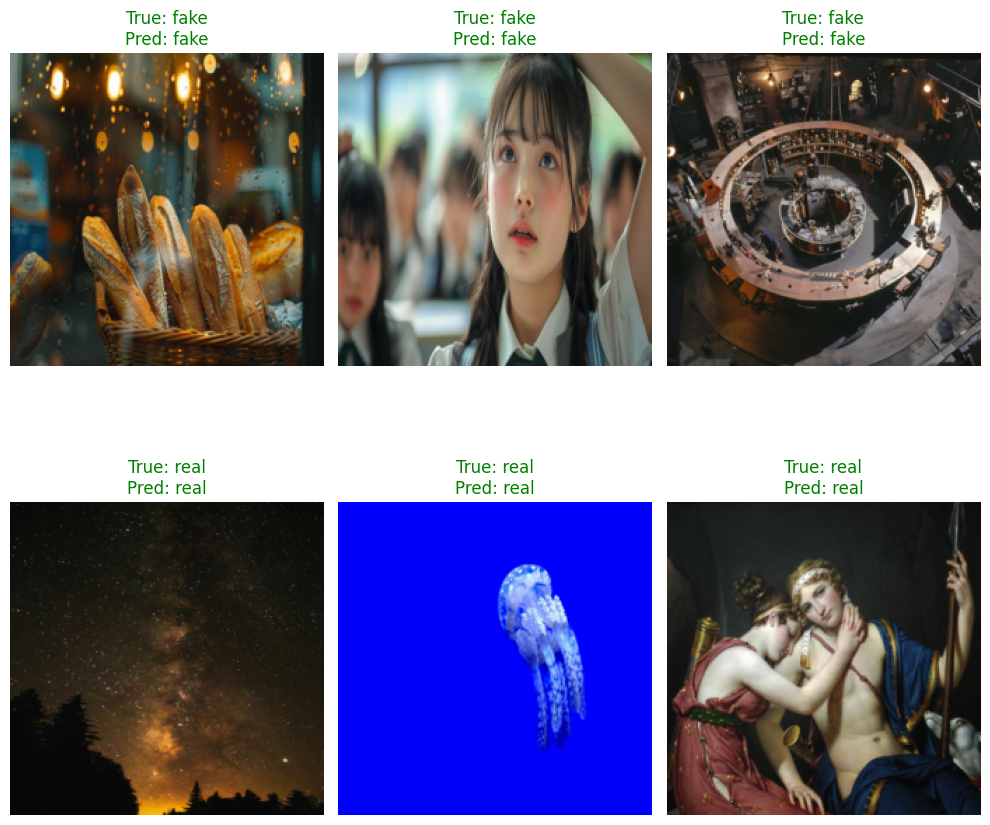

In [31]:
# Getting the list of class names ('fake', 'real') from the validation dataset.
class_names = val_dataset.classes

# Visualising predictions made by the trained model
helper_utils.visualize_predictions(trained_model, val_loader, DEVICE, class_names)

In [32]:
image_path = './images\\wolf.jpg'

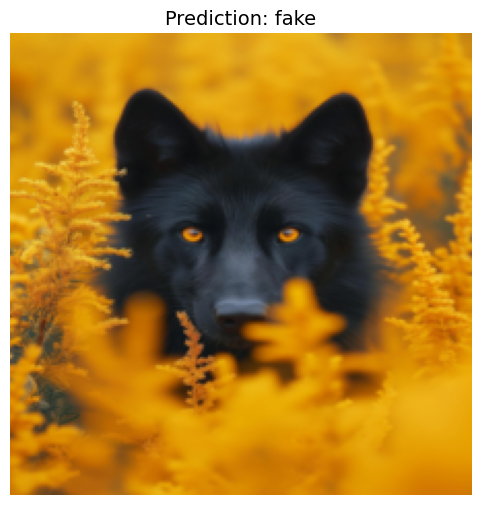

In [33]:
helper_utils.make_predictions(trained_model, image_path, DEVICE, class_names)